In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv")

df = df.sort_values(["Country", "Year"]).reset_index(drop=True)


In [ ]:
print("Shape:", df.shape)
display(df.head())

df.info()


Shape: (155, 27)


,Country,Year,D_Expenditure_GDP,Conflict_Intensity,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",Refugees,Asylum Seekers,...,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,CHN,1994,1.693480,NaN,NaN,1.98571,2.56,NaN,113908,0,...,3.216,2.522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHN,1995,1.686234,NaN,NaN,1.84192,2.79,NaN,104691,0,...,3.326,2.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHN,1996,1.652727,NaN,NaN,1.85339,2.74,NaN,105806,0,...,3.459,2.713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHN,1997,1.632651,NaN,NaN,NaN,2.79,NaN,106731,0,...,3.581,2.808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHN,1998,1.655081,NaN,NaN,1.84433,2.84,NaN,109396,0,...,3.592,2.817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 27 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   Country                                                                 155 non-null    object 
 1   Year                                                                    155 non-null    int64  
 2   D_Expenditure_GDP                                                       155 non-null    float64
 3   Conflict_Intensity                                                      0 non-null      float64
 4   Health_Expenditure_(% of GDP)                                           116 non-null    float64
 5   Education_Expenditure_(% of GDP)                                        125 non-null    float64
 6   Environmental impact (CO2e/capita)                                      150 non-nu

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100 ).round(2)

missing_df = pd.DataFrame({
    "Missing": missing,
    "Missing %": missing_pct
})

display(missing_df[missing_df["Missing"] > 0])

,Missing,Missing %
Conflict_Intensity,155,100.00
"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",155,100.00
Unnamed: 26,155,100.00
Unnamed: 19,155,100.00
Unnamed: 20,155,100.00
Unnamed: 21,155,100.00
Unnamed: 22,155,100.00
Unnamed: 23,155,100.00
Unnamed: 24,155,100.00
Unnamed: 25,155,100.00


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Year,155.0,2.009000e+03,8.973265e+00,1.994000e+03,2.001000e+03,2.009000e+03,2.017000e+03,2.024000e+03
D_Expenditure_GDP,155.0,2.778980e+00,1.026659e+00,1.605260e+00,1.924853e+00,2.422716e+00,3.505406e+00,7.052339e+00
Conflict_Intensity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Health_Expenditure_(% of GDP),116.0,9.234967e+00,4.139571e+00,3.674914e+00,5.166851e+00,9.722002e+00,1.149920e+01,1.881325e+01
Education_Expenditure_(% of GDP),125.0,4.753348e+00,1.123607e+00,1.841920e+00,3.988450e+00,4.929770e+00,5.554520e+00,6.738697e+00
Environmental impact (CO2e/capita),150.0,9.885333e+00,4.977291e+00,2.560000e+00,5.962500e+00,8.955000e+00,1.255750e+01,2.101000e+01
"PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)",0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Refugees,155.0,5.231060e+04,7.201012e+04,1.400000e+01,9.800000e+01,4.260000e+02,1.074135e+05,2.513940e+05
Asylum Seekers,155.0,1.449966e+04,3.131107e+04,0.000000e+00,4.300000e+01,2.660000e+02,1.544400e+04,1.809600e+05
Total number of deaths,155.0,3.982581e+01,2.508682e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.753000e+03


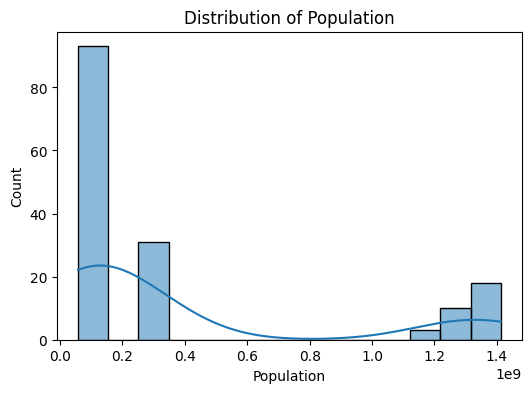

In [ ]:
targets = ["Population"]

for col in targets:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()

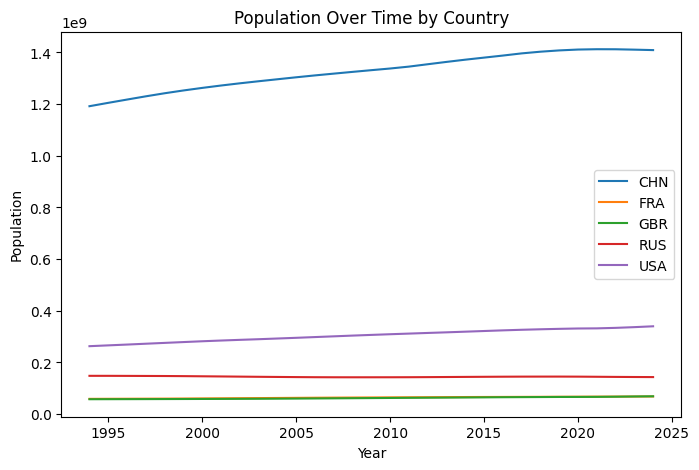

In [ ]:
for col in targets:
    plt.figure(figsize=(8,5))
    for country in df["Country"].unique():
        subset = df[df["Country"] == country]
        plt.plot(subset["Year"], subset[col], label=country)
    plt.title(f"{col} Over Time by Country")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.legend()
    plt.show()


In [ ]:
empty_cols = [col for col in df.columns if df[col].isnull().sum() == df.shape[0]]
df = df.drop(columns=empty_cols)

In [ ]:
df

,Country,Year,D_Expenditure_GDP,Health_Expenditure_(% of GDP),Education_Expenditure_(% of GDP),Environmental impact (CO2e/capita),Refugees,Asylum Seekers,Total number of deaths,Population,GDP_Growth_Annual,GDP_PerCapita_Growth_Annual,GDP_Current_USDollars,Inflation_Annual,Unemployment_Total_of_TLF,Unemployment_Male_of_TMF,Unemployment_Female_of_TFF
0,CHN,1994,1.693480,NaN,1.985710,2.56,113908,0,0,1191835000,13.072710,11.801890,5.670000e+11,24.256990,2.900,3.216,2.522
1,CHN,1995,1.686234,NaN,1.841920,2.79,104691,0,0,1204855000,11.032810,9.832961,7.380000e+11,16.791230,3.000,3.326,2.609
2,CHN,1996,1.652727,NaN,1.853390,2.74,105806,0,0,1217550000,9.976200,8.829514,8.690000e+11,8.313160,3.120,3.459,2.713
3,CHN,1997,1.632651,NaN,NaN,2.79,106731,0,4,1230075000,9.287647,8.174846,9.680000e+11,2.786465,3.230,3.581,2.808
4,CHN,1998,1.655081,NaN,1.844330,2.84,109396,0,0,1241935000,7.920792,6.890190,1.040000e+12,-0.773190,3.240,3.592,2.817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,USA,2020,3.650514,18.813253,5.395320,13.46,349,2491,0,331577720,-2.163030,-2.561810,2.140000e+13,1.233584,8.055,7.807,8.356
151,USA,2021,3.417094,17.506386,5.420380,14.31,426,1662,0,332099760,6.055053,5.888341,2.370000e+13,4.697859,5.349,5.463,5.210
152,USA,2022,3.343259,16.496140,5.382429,14.33,1327,2115,0,334017321,2.512375,1.923862,2.600000e+13,8.002800,3.650,3.680,3.613
153,USA,2023,3.361836,NaN,NaN,13.90,1229,2051,0,336806231,2.887556,2.035600,2.770000e+13,4.116338,3.638,3.795,3.450


In [ ]:
!pip install pmdarima

import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')

df.sort_values(['Country', 'Year'], inplace=True)


In [ ]:
TARGET = 'Population'

EXOG_COLS = [
    'D_Expenditure_GDP',
    'Conflict_Intensity',
    'Health_Expenditure_(% of GDP)',
    'Education_Expenditure_(% of GDP)',
    'Environmental impact (CO2e/capita)',
    'PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)',
    'GDP_Growth_Annual',
    'GDP_PerCapita_Growth_Annual',
    'Inflation_Annual',
    'Unemployment_Total_of_TLF'
]



PROCESSING: CHN
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=56.299, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.325, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=50.060, Time=0.04 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=59.004, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=51.081, Time=0.07 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=50.236, Time=0.03 sec

Best model:  ARIMA(0,2,1)(0,0,0)[0] intercept
Total fit time: 0.579 seconds
Best ARIMA model: (0, 2, 1)

 PERFORMANCE METRICS:
   R² Score: -88.0977
   MAE: 9,552,250 people
   RMSE: 11,486,699 people
   MAPE: 0.68%
   sMAPE: 0.67%
   Avg % Error: 0.68%


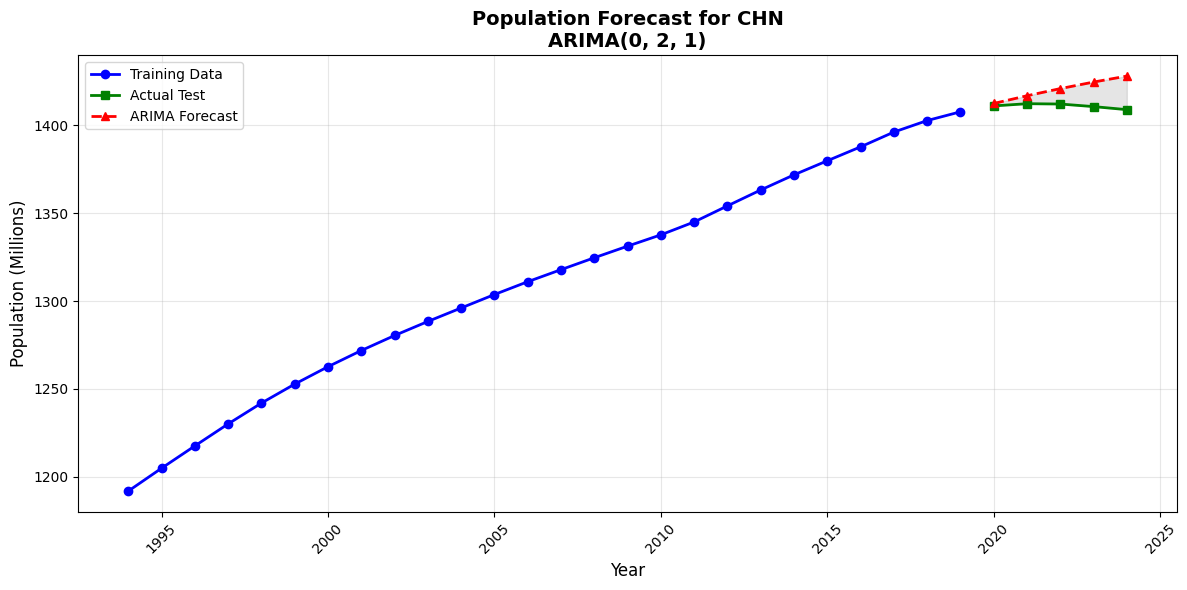


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=1,411,100,000, Predicted=1,412,481,482, Error=-0.10%
   2021: Actual=1,412,360,000, Predicted=1,416,883,415, Error=-0.32%
   2022: Actual=1,412,175,000, Predicted=1,420,950,799, Error=-0.62%
   2023: Actual=1,410,710,000, Predicted=1,424,683,634, Error=-0.99%
   2024: Actual=1,408,975,000, Predicted=1,428,081,920, Error=-1.36%

PROCESSING: FRA
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-43.108, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-82.897, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=18.386, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-92.927, Time=0.10 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-95.093, Time=0.23 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-99.854, Time=0.23 sec
 ARIMA(5,1,0)(0,0,0)[0] int

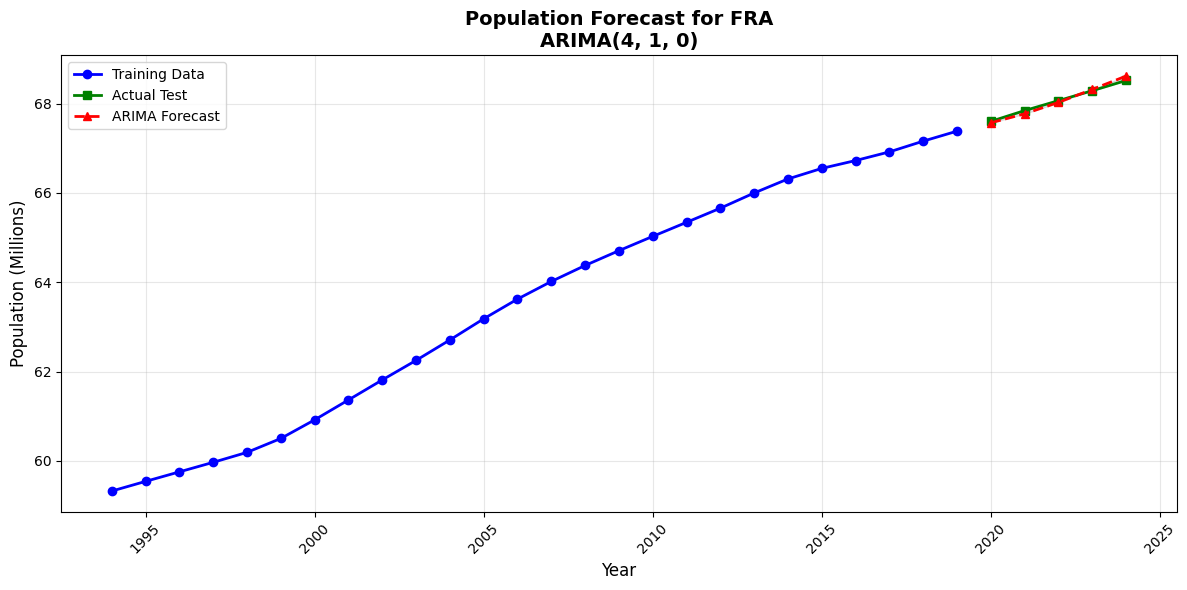


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=67,601,110, Predicted=67,569,170, Error=+0.05%
   2021: Actual=67,842,811, Predicted=67,770,711, Error=+0.11%
   2022: Actual=68,065,015, Predicted=68,025,747, Error=+0.06%
   2023: Actual=68,287,487, Predicted=68,317,230, Error=-0.04%
   2024: Actual=68,516,699, Predicted=68,615,107, Error=-0.14%

PROCESSING: GBR
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-76.837, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-75.125, Time=0.05 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-75.081, Time=0.10 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-78.113, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-73.268, Time=0.17 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.366 seconds
Best ARIMA model: (0, 2, 0)

 PERFORMANCE METRICS:
   R² Score: 0.7250
   MAE: 398,200 people
   RMSE: 48

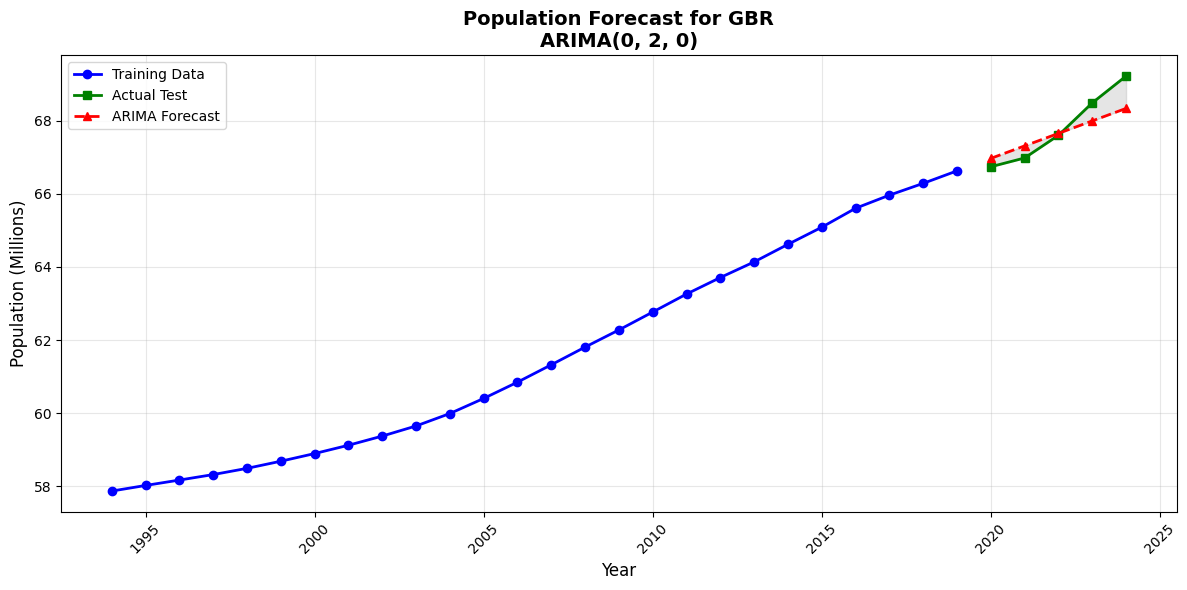


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=66,744,000, Predicted=66,973,000, Error=-0.34%
   2021: Actual=66,984,000, Predicted=67,315,000, Error=-0.49%
   2022: Actual=67,604,000, Predicted=67,657,000, Error=-0.08%
   2023: Actual=68,492,000, Predicted=67,999,000, Error=+0.72%
   2024: Actual=69,226,000, Predicted=68,341,000, Error=+1.28%

PROCESSING: RUS
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-32.147, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-42.614, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-47.158, Time=0.13 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-34.122, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-46.628, Time=0.16 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=-46.562, Time=0.08 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=-45.498, Time=0.24 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=-49.159, T

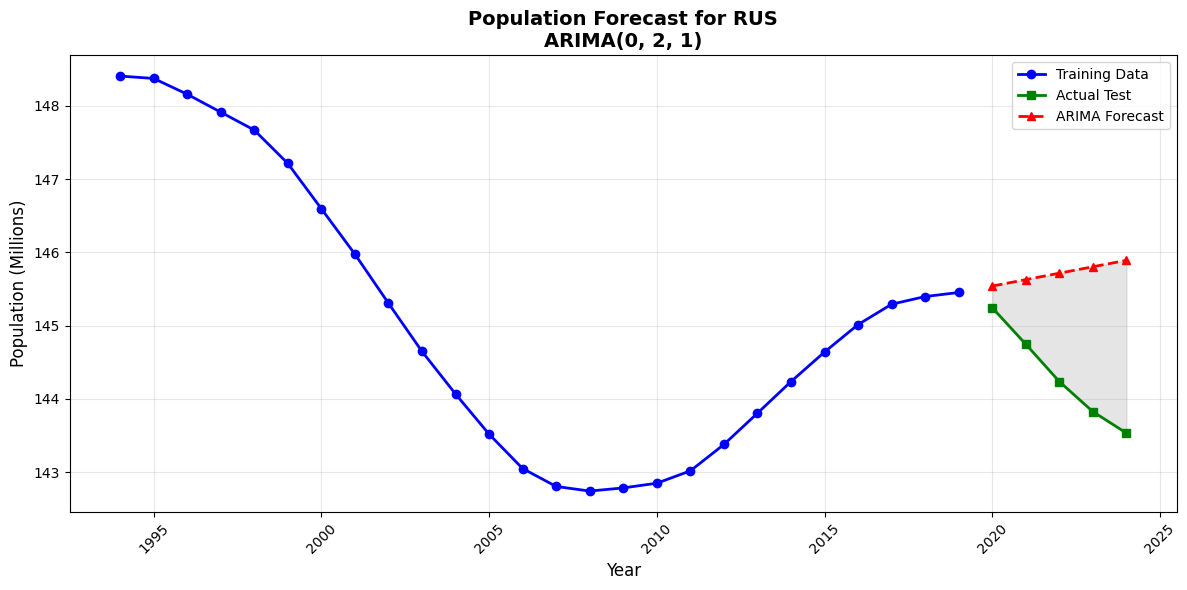


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=145,245,148, Predicted=145,541,180, Error=-0.20%
   2021: Actual=144,746,762, Predicted=145,629,068, Error=-0.61%
   2022: Actual=144,236,933, Predicted=145,716,957, Error=-1.03%
   2023: Actual=143,826,130, Predicted=145,804,846, Error=-1.38%
   2024: Actual=143,533,851, Predicted=145,892,735, Error=-1.64%

PROCESSING: USA
Data range: 1994 - 2024
Total years: 31
Training ARIMA on 26 years, testing on 5 years...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-20.616, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-20.677, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=-19.924, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-18.742, Time=0.05 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=-19.569, Time=0.06 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-18.831, Time=0.10 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=-20.688, Time=0.12 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=

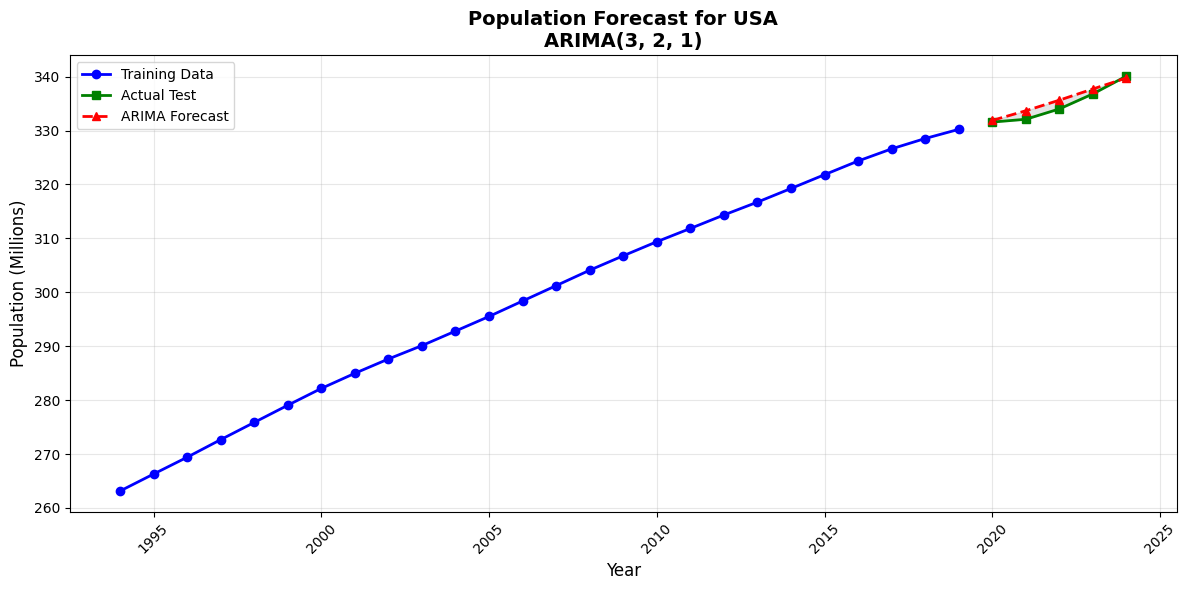


 YEAR-BY-YEAR PREDICTIONS:
   2020: Actual=331,577,720, Predicted=331,888,629, Error=-0.09%
   2021: Actual=332,099,760, Predicted=333,676,971, Error=-0.47%
   2022: Actual=334,017,321, Predicted=335,645,062, Error=-0.49%
   2023: Actual=336,806,231, Predicted=337,721,470, Error=-0.27%
   2024: Actual=340,110,988, Predicted=339,761,427, Error=+0.10%

 OVERALL PERFORMANCE SUMMARY

Total countries analyzed: 5

Average Metrics Across All Countries:
  Average R² Score: -18.2210
  Average MAE: 2,472,013 people
  Average RMSE: 2,946,346 people
  Average MAPE: 0.52%
  Average sMAPE: 0.52%

 TOP 3 PERFORMING COUNTRIES (by R²):
  1. FRA: R²=0.9646, MAPE=0.08%
  2. USA: R²=0.8772, MAPE=0.29%
  3. GBR: R²=0.7250, MAPE=0.58%

 BOTTOM 3 PERFORMING COUNTRIES (by R²):
  3. GBR: R²=0.7250, MAPE=0.58%
  4. RUS: R²=-5.5744, MAPE=0.97%
  5. CHN: R²=-88.0977, MAPE=0.68%

🔧 MOST COMMON ARIMA ORDERS:
  (0, 2, 1): 2 countries
  (4, 1, 0): 1 countries
  (3, 2, 1): 1 countries
  (0, 2, 0): 1 countries


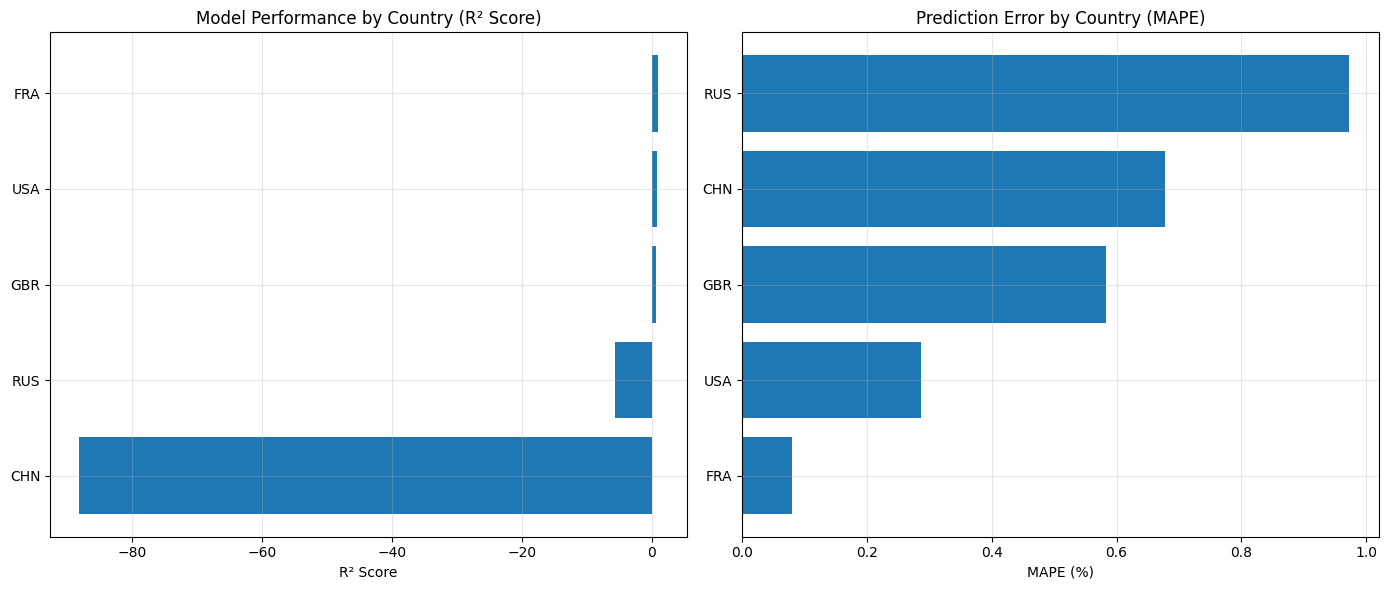


 Metrics and predictions saved to CSV files!
Files created:
   - arima_population_metrics_enhanced.csv
   - arima_population_comparison_enhanced.csv

FUTURE FORECAST EXAMPLE

 FUTURE FORECAST FOR CHN
ARIMA Model: (1, 2, 0)
  2025: 1,406,877,680 (Δ -0.15%)
  2026: 1,404,364,405 (Δ -0.18%)
  2027: 1,401,404,016 (Δ -0.21%)
  2028: 1,397,978,410 (Δ -0.24%)
  2029: 1,394,077,069 (Δ -0.28%)

SAVING ARIMA MODELS TO .h5 FORMAT
ARIMA models saved to: arima_population_model.h5
   File size: 32.38 KB
   Countries saved: ['CHN', 'FRA', 'GBR', 'RUS', 'USA']

SAVING COMPLETE!

 File saved at: /content/arima_population_model.h5



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 TO VIEW THE H5 FILE CONTENTS:
   import h5py
   with h5py.File('arima_population_model.h5', 'r') as f:
       print('Model type:', f.attrs['model_type'])
       print('Countries:', list(f['models'].keys()))
       for country in f['models'].keys():
           print(f"{country}: {f['models'][country].attrs['order']}")


In [3]:
!pip install pmdarima

import pandas as pd
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
import h5py
import os
from datetime import datetime
warnings.filterwarnings('ignore')

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv')
df.sort_values(['Country', 'Year'], inplace=True)
countries = df['Country'].unique()
test_years = [2020, 2021, 2022, 2023, 2024]

all_metrics = []
all_comparison = []
all_models = {}  # Store models for each country

# ==========================
# FUNCTION: sMAPE
# ==========================
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10))

# ==========================
# ENHANCED VISUALIZATION FUNCTION
# ==========================
def plot_country_forecast(country, train_years, train_values, test_years, test_values, forecast_values, model_order):
    """Plot training, actual test, and forecasted values"""
    plt.figure(figsize=(12, 6))

    # Plot training data
    plt.plot(train_years, train_values, 'b-', label='Training Data', linewidth=2, marker='o')

    # Plot test actual values
    plt.plot(test_years, test_values, 'g-', label='Actual Test', linewidth=2, marker='s')

    # Plot forecast
    plt.plot(test_years, forecast_values, 'r--', label='ARIMA Forecast', linewidth=2, marker='^')

    # Shade forecast area
    plt.fill_between(test_years, test_values, forecast_values, alpha=0.2, color='gray')

    plt.title(f'Population Forecast for {country}\nARIMA{model_order}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Population (Millions)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================
# LOOP PER COUNTRY
# ==========================
for country in countries:
    print(f"\n{'='*60}")
    print(f"PROCESSING: {country}")
    print('='*60)

    country_df = df[df['Country'] == country].copy()

    # Display data info
    print(f"Data range: {country_df['Year'].min()} - {country_df['Year'].max()}")
    print(f"Total years: {len(country_df)}")

    # Scale population to millions for ARIMA stability
    country_df['Population_Millions'] = country_df['Population'] / 1_000_000

    # Split train/test
    train_df = country_df[~country_df['Year'].isin(test_years)]
    test_df = country_df[country_df['Year'].isin(test_years)]

    if len(test_df) == 0:
        print(f"No test data for {country} in years {test_years}")
        continue

    if len(train_df) < 10:
        print(f"Insufficient training data for {country} ({len(train_df)} years)")
        continue

    ts_train = train_df['Population_Millions'].values
    ts_test = test_df['Population_Millions'].values
    years_train = train_df['Year'].values
    years_test = test_df['Year'].values

    # Fit ARIMA model with more options
    try:
        print(f"Training ARIMA on {len(ts_train)} years, testing on {len(ts_test)} years...")

        model = auto_arima(
            ts_train,
            start_p=0, start_q=0,
            max_p=5, max_q=5,
            d=None,  # Let auto_arima determine differencing
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=True,  # Show model search process
            n_jobs=-1,   # Use all CPU cores
            random_state=42
        )

        print(f"Best ARIMA model: {model.order}")

        # Store model
        all_models[country] = model

        # Generate forecast
        forecast_scaled = model.predict(n_periods=len(ts_test))

        # Scale back to actual population
        forecast = forecast_scaled * 1_000_000
        actual = ts_test * 1_000_000

        # Calculate metrics
        r2 = r2_score(actual, forecast)
        mae = mean_absolute_error(actual, forecast)
        rmse = np.sqrt(mean_squared_error(actual, forecast))
        smape_val = smape(actual, forecast)
        mape_val = np.mean(np.abs((actual - forecast) / actual)) * 100

        # Calculate percentage errors
        pct_errors = np.abs((actual - forecast) / actual) * 100
        avg_pct_error = np.mean(pct_errors)

        print(f"\n PERFORMANCE METRICS:")
        print(f"   R² Score: {r2:.4f}")
        print(f"   MAE: {mae:,.0f} people")
        print(f"   RMSE: {rmse:,.0f} people")
        print(f"   MAPE: {mape_val:.2f}%")
        print(f"   sMAPE: {smape_val:.2f}%")
        print(f"   Avg % Error: {avg_pct_error:.2f}%")

        # Store metrics
        all_metrics.append({
            'Country': country,
            'Train_Years': f"{years_train[0]}-{years_train[-1]}",
            'Test_Years': f"{years_test[0]}-{years_test[-1]}",
            'Train_Size': len(ts_train),
            'Test_Size': len(ts_test),
            'ARIMA_Order': str(model.order),
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape_val,
            'sMAPE': smape_val,
            'Avg_Pct_Error': avg_pct_error,
            'AIC': model.aic(),
            'BIC': model.bic()
        })

        # Year-by-year comparison
        for y, a, f, pct_err in zip(years_test, actual, forecast, pct_errors):
            all_comparison.append({
                'Country': country,
                'Year': y,
                'Population_Actual': a,
                'Population_Predicted': f,
                'Difference': a - f,
                'Pct_Error': pct_err
            })

        # Plot results
        plot_country_forecast(
            country,
            years_train,
            ts_train,
            years_test,
            ts_test,
            forecast_scaled,
            model.order
        )

        # Print year-by-year performance
        print(f"\n YEAR-BY-YEAR PREDICTIONS:")
        for i, (y, a, f) in enumerate(zip(years_test, actual, forecast)):
            error_pct = ((a - f) / a) * 100
            print(f"   {y}: Actual={a:,.0f}, Predicted={f:,.0f}, Error={error_pct:+.2f}%")

    except Exception as e:
        print(f" Error for {country}: {e}")

# ==========================
# SAVE AND DISPLAY RESULTS
# ==========================
if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    comparison_df = pd.DataFrame(all_comparison)

    # Sort metrics by R² score
    metrics_df = metrics_df.sort_values('R2', ascending=False).reset_index(drop=True)

    # Save results
    metrics_df.to_csv('arima_population_metrics_enhanced.csv', index=False)
    comparison_df.to_csv('arima_population_comparison_enhanced.csv', index=False)

    print("\n" + "="*60)
    print(" OVERALL PERFORMANCE SUMMARY")
    print("="*60)

    # Display summary statistics
    print(f"\nTotal countries analyzed: {len(metrics_df)}")
    print(f"\nAverage Metrics Across All Countries:")
    print(f"  Average R² Score: {metrics_df['R2'].mean():.4f}")
    print(f"  Average MAE: {metrics_df['MAE'].mean():,.0f} people")
    print(f"  Average RMSE: {metrics_df['RMSE'].mean():,.0f} people")
    print(f"  Average MAPE: {metrics_df['MAPE'].mean():.2f}%")
    print(f"  Average sMAPE: {metrics_df['sMAPE'].mean():.2f}%")

    # Display best and worst performing countries
    print(f"\n TOP 3 PERFORMING COUNTRIES (by R²):")
    for i, row in metrics_df.head(3).iterrows():
        print(f"  {i+1}. {row['Country']}: R²={row['R2']:.4f}, MAPE={row['MAPE']:.2f}%")

    print(f"\n BOTTOM 3 PERFORMING COUNTRIES (by R²):")
    for i, row in metrics_df.tail(3).iterrows():
        print(f"  {i+1}. {row['Country']}: R²={row['R2']:.4f}, MAPE={row['MAPE']:.2f}%")

    # Display most common ARIMA orders
    print(f"\n🔧 MOST COMMON ARIMA ORDERS:")
    order_counts = metrics_df['ARIMA_Order'].value_counts()
    for order, count in order_counts.head(5).items():
        print(f"  {order}: {count} countries")

    # Create a summary visualization
    plt.figure(figsize=(14, 6))

    # Subplot 1: R² scores by country
    plt.subplot(1, 2, 1)
    sorted_idx = np.argsort(metrics_df['R2'])
    plt.barh(range(len(metrics_df)), metrics_df['R2'].iloc[sorted_idx])
    plt.yticks(range(len(metrics_df)), metrics_df['Country'].iloc[sorted_idx])
    plt.xlabel('R² Score')
    plt.title('Model Performance by Country (R² Score)')
    plt.grid(True, alpha=0.3)

    # Subplot 2: MAPE by country
    plt.subplot(1, 2, 2)
    sorted_idx_mape = np.argsort(metrics_df['MAPE'])
    plt.barh(range(len(metrics_df)), metrics_df['MAPE'].iloc[sorted_idx_mape])
    plt.yticks(range(len(metrics_df)), metrics_df['Country'].iloc[sorted_idx_mape])
    plt.xlabel('MAPE (%)')
    plt.title('Prediction Error by Country (MAPE)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n Metrics and predictions saved to CSV files!")
    print("Files created:")
    print("   - arima_population_metrics_enhanced.csv")
    print("   - arima_population_comparison_enhanced.csv")

else:
    print("\n No models were successfully trained. Check your data and error messages.")

# ==========================
# BONUS: FUTURE FORECASTING FUNCTION
# ==========================
def forecast_future_population(country_name, forecast_years=5):
    """Forecast population for future years"""
    country_df = df[df['Country'] == country_name].copy()

    if len(country_df) == 0:
        print(f"Country '{country_name}' not found in dataset.")
        return None

    # Scale population
    country_df['Population_Millions'] = country_df['Population'] / 1_000_000
    ts_full = country_df['Population_Millions'].values

    # Train on all available data
    try:
        model = auto_arima(
            ts_full,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True
        )

        print(f"\n FUTURE FORECAST FOR {country_name}")
        print(f"ARIMA Model: {model.order}")

        # Generate future forecast
        future_scaled = model.predict(n_periods=forecast_years)
        future_population = future_scaled * 1_000_000

        # Create forecast dataframe
        last_year = country_df['Year'].max()
        future_years = list(range(last_year + 1, last_year + forecast_years + 1))

        forecast_df = pd.DataFrame({
            'Country': country_name,
            'Year': future_years,
            'Population_Forecast': future_population
        })

        # Calculate growth rates
        last_pop = country_df['Population'].iloc[-1]
        for i in range(len(forecast_df)):
            if i == 0:
                growth_pct = ((forecast_df['Population_Forecast'].iloc[i] - last_pop) / last_pop) * 100
            else:
                growth_pct = ((forecast_df['Population_Forecast'].iloc[i] -
                             forecast_df['Population_Forecast'].iloc[i-1]) /
                            forecast_df['Population_Forecast'].iloc[i-1]) * 100

            print(f"  {forecast_df['Year'].iloc[i]}: {forecast_df['Population_Forecast'].iloc[i]:,.0f} "
                  f"(Δ {growth_pct:+.2f}%)")

        return forecast_df

    except Exception as e:
        print(f"Error forecasting for {country_name}: {e}")
        return None

# Example: Forecast next 5 years for a specific country
if len(countries) > 0:
    print("\n" + "="*60)
    print("FUTURE FORECAST EXAMPLE")
    print("="*60)
    forecast_df = forecast_future_population(countries[0], forecast_years=5)

# ==========================
# ADDED: SAVE ARIMA MODEL TO .h5 FORMAT (ONLY H5, NO PKL)
# ==========================
def save_arima_to_h5(models_dict, metrics_df, filename='arima_population_model.h5'):
    """
    Save ARIMA models to .h5 format only (no pickle)
    """
    print("\n" + "="*60)
    print("SAVING ARIMA MODELS TO .h5 FORMAT")
    print("="*60)

    with h5py.File(filename, 'w') as f:

        # 1. Save metadata
        f.attrs['model_type'] = 'ARIMA Population Predictor'
        f.attrs['n_countries'] = len(models_dict)
        f.attrs['created_date'] = str(datetime.now())
        f.attrs['test_years'] = str(test_years)

        # 2. Save metrics summary
        if metrics_df is not None:
            metrics_group = f.create_group('metrics_summary')
            for col in metrics_df.columns:
                if metrics_df[col].dtype in ['float64', 'int64']:
                    metrics_group.attrs[f'avg_{col}'] = float(metrics_df[col].mean())
                    metrics_group.attrs[f'std_{col}'] = float(metrics_df[col].std())

        # 3. Save each country's model
        models_group = f.create_group('models')

        for country, model in models_dict.items():
            country_group = models_group.create_group(country)

            # Get country metrics
            country_metrics = metrics_df[metrics_df['Country'] == country].iloc[0] if len(metrics_df) > 0 else None

            # Save model parameters
            country_group.attrs['order'] = str(model.order)
            country_group.attrs['aic'] = float(model.aic()) if model.aic() else 0
            country_group.attrs['bic'] = float(model.bic()) if model.bic() else 0

            if country_metrics is not None:
                country_group.attrs['r2'] = float(country_metrics['R2'])
                country_group.attrs['mae'] = float(country_metrics['MAE'])
                country_group.attrs['rmse'] = float(country_metrics['RMSE'])
                country_group.attrs['mape'] = float(country_metrics['MAPE'])
                country_group.attrs['arima_order'] = country_metrics['ARIMA_Order']

            # Save ARIMA model parameters (p,d,q)
            params_group = country_group.create_group('params')
            params_group.attrs['p'] = model.order[0]
            params_group.attrs['d'] = model.order[1]
            params_group.attrs['q'] = model.order[2]

            # Save model coefficients if available
            if hasattr(model, 'arparams_') and model.arparams_ is not None:
                params_group.create_dataset('ar_params', data=model.arparams_)
            if hasattr(model, 'maparams_') and model.maparams_ is not None:
                params_group.create_dataset('ma_params', data=model.maparams_)

            # Save training data info
            train_data = df[df['Country'] == country]['Population'].values
            if len(train_data) > 0:
                data_group = country_group.create_group('training_data')
                data_group.create_dataset('population', data=train_data)
                years_data = df[df['Country'] == country]['Year'].values
                data_group.create_dataset('years', data=years_data)

    file_size = os.path.getsize(filename) / 1024
    print(f"ARIMA models saved to: {filename}")
    print(f"   File size: {file_size:.2f} KB")
    print(f"   Countries saved: {list(models_dict.keys())}")

    return filename

# ==========================
# SAVE THE MODELS (ONLY H5)
# ==========================
if len(all_models) > 0:
    h5_file = save_arima_to_h5(all_models, metrics_df, 'arima_population_model.h5')

    print("\n" + "="*60)
    print("SAVING COMPLETE!")
    print("="*60)
    print(f"\n File saved at: {os.path.abspath('arima_population_model.h5')}")

    # Optional: Download in Colab
    try:
        from google.colab import files
        print("\n Downloading file to your computer...")
        files.download('arima_population_model.h5')
    except:
        pass

    print("\n TO VIEW THE H5 FILE CONTENTS:")
    print("   import h5py")
    print("   with h5py.File('arima_population_model.h5', 'r') as f:")
    print("       print('Model type:', f.attrs['model_type'])")
    print("       print('Countries:', list(f['models'].keys()))")
    print("       for country in f['models'].keys():")
    print("           print(f\"{country}: {f['models'][country].attrs['order']}\")")
else:
    print("\n No models to save!")